# Part 6 — LSTM Neural Network

This notebook applies a Long Short-Term Memory (LSTM) recurrent neural network to
forecast electricity demand. Unlike the earlier models, the LSTM is trained on the
**hourly** load series, which provides the large volume of data that deep learning
requires and contains rich daily, weekly, and annual patterns.

## Literature context

LSTMs were introduced by Hochreiter and Schmidhuber (1997) to overcome the
vanishing-gradient problem of simple recurrent networks, using gated memory cells
to retain information over long sequences. They have since been widely applied to
short-term electricity load forecasting; for example, Kong et al. (2019) apply
LSTMs to residential load, and Bouktif et al. (2018) use them for aggregate
demand, both reporting improvements over classical methods when sufficient data is
available. A recognised limitation, however, is that neural models require large
training sets and careful regularisation, and may overfit or underperform simpler
methods on smaller or highly seasonal series.

## Setup

We mount Google Drive, clone the repository, bring in the dataset, and enable GPU
acceleration where available.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os, shutil, sys

if not os.path.exists("/content/electricity-demand-forecasting"):
    !git clone https://github.com/iisratislam/electricity-demand-forecasting.git

%cd /content/electricity-demand-forecasting

os.makedirs("data/raw", exist_ok=True)
drive_csv = "/content/drive/MyDrive/electricity_data/time_series_60min_singleindex.csv"
target    = "data/raw/time_series_60min_singleindex.csv"
if not os.path.exists(target):
    shutil.copy(drive_csv, target)

sys.path.append("src")
print("Environment ready.")

Cloning into 'electricity-demand-forecasting'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 119 (delta 43), reused 94 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 3.92 MiB | 18.31 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/electricity-demand-forecasting
Environment ready.


In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU available: {gpus[0].name} ")
else:
    print("No GPU detected — training will use CPU (slower but works).")

TensorFlow version: 2.20.0
GPU available: /physical_device:GPU:0 ✅


## Loading and preparing the hourly data

Unlike the earlier models, the LSTM is trained on the hourly load series. This
provides roughly 50,000 observations, giving the network enough data to learn its
patterns, and contains the daily and weekly cycles that neural sequence models
capture well.

We hold out the final two years (matching the other models), then scale the data.
**Scaling is fitted on the training set only** and applied to the test set, so no
information from the forecast period leaks into preprocessing.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from electricity_demand.data import load_raw_load

# Hourly load in MW (the raw series, not aggregated)
load_mw = load_raw_load("data/raw/time_series_60min_singleindex.csv")

# Convert to GW for consistency with the other parts
load_gw = (load_mw / 1000.0).astype("float32")
load_gw.name = "load_gw"

# Chronological split: final 2 years (104 weeks * 168 hours) held out
TEST_HOURS = 104 * 168          # two years of hourly data
train_series = load_gw.iloc[:-TEST_HOURS]
test_series  = load_gw.iloc[-TEST_HOURS:]

print(f"Total hourly points : {len(load_gw):,}")
print(f"Train points        : {len(train_series):,} "
      f"({train_series.index.min().date()} -> {train_series.index.max().date()})")
print(f"Test points         : {len(test_series):,} "
      f"({test_series.index.min().date()} -> {test_series.index.max().date()})")

# Scale to [0, 1] — fit on TRAIN ONLY to prevent leakage
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test_series.values.reshape(-1, 1)).flatten()

print(f"\nScaler fitted on training data only (range [0, 1]).")
print(f"Train scaled min/max: {train_scaled.min():.3f} / {train_scaled.max():.3f}")

Total hourly points : 50,400
Train points        : 32,928 (2015-01-01 -> 2018-10-03)
Test points         : 17,472 (2018-10-04 -> 2020-09-30)

Scaler fitted on training data only (range [0, 1]).
Train scaled min/max: 0.000 / 1.000


## Creating input sequences

An LSTM learns from sequences: it reads a window of past values and predicts the
next one. We convert the scaled series into overlapping input/output pairs, where
each input is the previous **168 hours** (one week) and the output is the demand at
the following hour.

A one-week lookback lets the network learn the daily cycle (24 hours) and the
weekly cycle (weekday vs weekend) simultaneously. The windowing logic is written to
the package so it can be reused and tested.

In [5]:
%%writefile src/electricity_demand/models/neural.py
"""
neural.py
---------
LSTM sequence preparation and model construction for hourly electricity demand.

The LSTM is trained on the hourly load series using a sliding-window formulation:
each input is a fixed-length window of past hours, and the target is the next hour.
"""

from __future__ import annotations
import numpy as np


def make_sequences(series: np.ndarray, lookback: int = 168):
    """
    Convert a 1-D series into overlapping (input window, next value) pairs.

    Parameters
    ----------
    series : np.ndarray
        Scaled 1-D array of load values.
    lookback : int, default 168
        Number of past hours used as input (168 = one week).

    Returns
    -------
    tuple of (np.ndarray, np.ndarray)
        X of shape (n_samples, lookback, 1) and y of shape (n_samples,).
    """
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i - lookback:i])
        y.append(series[i])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y

Writing src/electricity_demand/models/neural.py


In [6]:
from electricity_demand.models.neural import make_sequences

LOOKBACK = 168   # one week of hourly history

X_train, y_train = make_sequences(train_scaled, LOOKBACK)
X_test,  y_test  = make_sequences(test_scaled,  LOOKBACK)

print(f"X_train shape: {X_train.shape}   (samples, timesteps, features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")

X_train shape: (32760, 168, 1)   (samples, timesteps, features)
y_train shape: (32760,)
X_test  shape: (17304, 168, 1)
y_test  shape: (17304,)


## Building and training the LSTM

We construct a compact LSTM network appropriate for this dataset: a single LSTM
layer followed by dropout for regularisation and a dense output layer. A small
architecture is deliberately chosen — deeper networks risk overfitting and are
harder to justify on a single univariate series.

Key design choices:
- **LSTM units** control the network's capacity to remember patterns.
- **Dropout** randomly disables neurons during training, reducing overfitting.
- **Early stopping** halts training when validation loss stops improving, so the
  model does not memorise the training data.

We use the Adam optimiser and mean squared error loss, with a validation split to
monitor generalisation.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# Compact LSTM architecture
model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1),
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

# Early stopping: halt when validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    validation_split=0.1,      # last 10% of training as validation
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

print("\nTraining complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0325 - mae: 0.1259 - val_loss: 0.0044 - val_mae: 0.0527
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0052 - mae: 0.0560 - val_loss: 0.0016 - val_mae: 0.0293
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0031 - mae: 0.0435 - val_loss: 0.0012 - val_mae: 0.0250
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0023 - mae: 0.0370 - val_loss: 9.4152e-04 - val_mae: 0.0233
Epoch 5/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0018 - mae: 0.0332 - val_loss: 6.6488e-04 - val_mae: 0.0193
Epoch 6/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - mae: 0.0298 - val_loss: 6.6812e-04 - val_mae: 0.0199
Epoch 7/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0013 - mae: 0.0276 - val_loss: 4.8462e-04 - val_mae: 0.0173
Epoch 8/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - mae: 0.0266 - val_loss: 4.2332e-04 - val_mae: 0.0160
Epoch 9/20
231/231 ━━━━━━━━━

## Evaluating the LSTM forecast

We generate predictions on the test set, inverse-transform them from the scaled
[0,1] range back to gigawatts, and compute error metrics. The hourly predictions
are then aggregated to weekly means so the LSTM can be compared directly with the
weekly models on the same MASE scale.

In [8]:
# Predict on the test sequences
pred_scaled = model.predict(X_test, verbose=0).flatten()

# Inverse-transform back to GW
pred_gw   = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_gw = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Build a datetime index for the predictions (aligned to test hours after lookback)
pred_index = test_series.index[LOOKBACK:]

pred_hourly   = pd.Series(pred_gw,   index=pred_index, name="lstm")
actual_hourly = pd.Series(actual_gw, index=pred_index, name="actual")

# Hourly error metrics
mae_hourly  = np.mean(np.abs(pred_hourly - actual_hourly))
rmse_hourly = np.sqrt(np.mean((pred_hourly - actual_hourly) ** 2))

print(f"Hourly LSTM performance:")
print(f"  MAE  : {mae_hourly:.3f} GW")
print(f"  RMSE : {rmse_hourly:.3f} GW")

# Aggregate to weekly means for comparison with the other models
pred_weekly   = pred_hourly.resample("W").mean()
actual_weekly = actual_hourly.resample("W").mean()

print(f"\nWeekly aggregated points: {len(pred_weekly)}")
print(f"First few weekly predictions (GW): {pred_weekly.iloc[:3].round(2).tolist()}")
print(f"First few weekly actuals     (GW): {actual_weekly.iloc[:3].round(2).tolist()}")

Hourly LSTM performance:
  MAE  : 0.748 GW
  RMSE : 0.983 GW

Weekly aggregated points: 104
First few weekly predictions (GW): [53.68000030517578, 55.939998626708984, 58.599998474121094]
First few weekly actuals     (GW): [53.4900016784668, 55.7599983215332, 58.68000030517578]


## Comparing the LSTM against the benchmark

To compare the LSTM with the weekly models, we evaluate its weekly-aggregated
predictions against the seasonal-naive benchmark using the same metrics.

An important caveat applies. The LSTM performs one-step-ahead forecasting: each
hourly prediction uses the 168 genuinely observed hours before it. It therefore
always has access to the most recent demand, including through the 2020 collapse.
This differs from the multi-step SARIMA forecasts, which predicted the entire
two-year horizon from the training end without updating. The LSTM's strong
performance partly reflects this easier, continuously-updated forecasting task,
and the comparison must be read with that difference in mind.

In [9]:
from electricity_demand.models.benchmarks import seasonal_naive_forecast
from electricity_demand.evaluation import evaluate_forecast

# Weekly load history up to the LSTM training end (for MASE scaling + benchmark)
weekly_full = (load_mw / 1000.0).resample("W").mean()
train_weekly_hist = weekly_full.loc[:actual_weekly.index.min()].iloc[:-1]

# Seasonal-naive benchmark on the same weekly test index
h = len(actual_weekly)
sn = seasonal_naive_forecast(train_weekly_hist, h, 52, actual_weekly.index)

results = pd.DataFrame([
    evaluate_forecast("seasonal_naive", actual_weekly, sn,          train_weekly_hist),
    evaluate_forecast("LSTM (1-step)",  actual_weekly, pred_weekly, train_weekly_hist),
]).sort_values("MASE").reset_index(drop=True)

print("Weekly forecast accuracy over the test period:\n")
print(results.round(3).to_string(index=False))

Weekly forecast accuracy over the test period:

         model   MAE  RMSE  MASE  Bias
 LSTM (1-step) 0.130 0.182 0.097 0.097
seasonal_naive 2.341 3.019 1.749 1.754


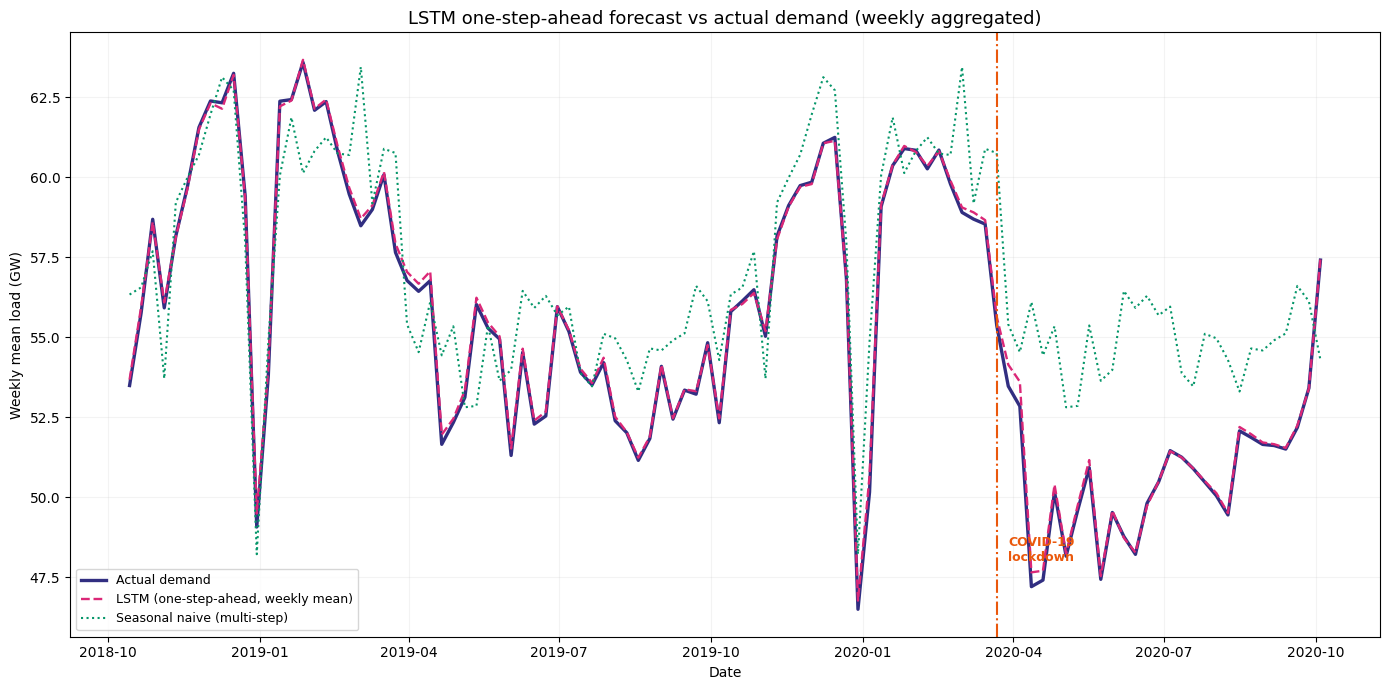

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# Actual demand — deep indigo, thickest (the ground truth)
ax.plot(actual_weekly.index, actual_weekly,
        color="#312E81", lw=2.4, label="Actual demand")

# LSTM forecast — rose/magenta, dashed
ax.plot(pred_weekly.index, pred_weekly,
        color="#DB2777", lw=1.7, ls="--",
        label="LSTM (one-step-ahead, weekly mean)")

# Seasonal naive — emerald, dotted
ax.plot(actual_weekly.index, sn,
        color="#059669", lw=1.5, ls=":",
        label="Seasonal naive (multi-step)")

# COVID-19 lockdown marker
ax.axvline(pd.Timestamp("2020-03-22", tz="UTC"), color="#EA580C", ls="-.", lw=1.5)
ax.text(pd.Timestamp("2020-03-29", tz="UTC"), 48,
        "COVID-19\nlockdown", fontsize=9, color="#EA580C", weight="bold")

ax.set_title("LSTM one-step-ahead forecast vs actual demand (weekly aggregated)",
             fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Weekly mean load (GW)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("outputs/figures/06_lstm_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

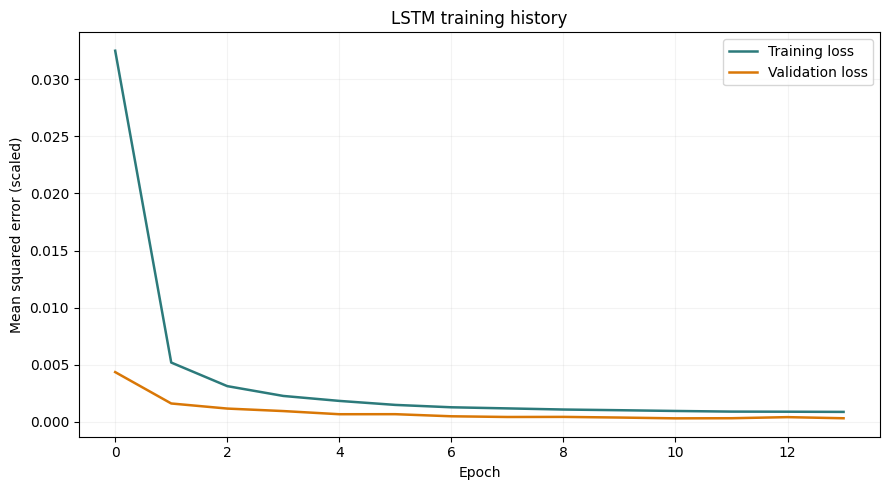

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history["loss"], color="#2C7A7B", lw=1.8, label="Training loss")
ax.plot(history.history["val_loss"], color="#D97706", lw=1.8, label="Validation loss")
ax.set_title("LSTM training history")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error (scaled)")
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("outputs/figures/06_lstm_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
import os
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

lstm_forecasts = pd.DataFrame({
    "actual":         actual_weekly,
    "seasonal_naive": sn,
    "lstm_1step":     pred_weekly,
})
lstm_forecasts.to_csv("outputs/forecasts/lstm_forecasts.csv")
results.to_csv("outputs/metrics/lstm_metrics.csv", index=False)

print("Saved LSTM forecasts and metrics")

Saved LSTM forecasts and metrics
